In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [83]:
df=pd.read_csv("train.csv")

In [84]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404290 entries, 0 to 404289
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            404290 non-null  int64 
 1   qid1          404290 non-null  int64 
 2   qid2          404290 non-null  int64 
 3   question1     404289 non-null  object
 4   question2     404288 non-null  object
 5   is_duplicate  404290 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 18.5+ MB


In [86]:
df.isnull().sum()

id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64

## Simple Approach

In [87]:
new_df=df.sample(30000)

In [88]:
new_df.duplicated().sum()

0

In [89]:
new_df.isnull().sum()

id              0
qid1            0
qid2            0
question1       0
question2       0
is_duplicate    0
dtype: int64

In [90]:
ques_df=new_df[['question1','question2']]
ques_df.head()

,question1,question2
17118,Is it theoritically possible to take a picture...,Can we change NIFT campus by money?
32795,Are any of the conspiracy theories actually true?,Were/are any conspiracy theories actually true?
266601,I asked before about passing my drug test but ...,I smoked a week and a half ago. also a regular...
283680,How can I enable OTG support in the Honor 4X?,Does Lumia 730 support OTG?
129101,What are some good words to describe a cat?,What is one word you would use to describe 2013?


In [91]:
from sklearn.feature_extraction.text import CountVectorizer

questions=list(ques_df['question1'])+list(ques_df['question2'])
questions

['Is it theoritically possible to take a picture of the camera used to take it?',
 'Are any of the conspiracy theories actually true?',
 "I asked before about passing my drug test but didn't give enough details, will I pass my drug test? (sorry to those who answered before)",
 'How can I enable OTG support in the Honor 4X?',
 'What are some good words to describe a cat?',
 'I want to know people checking on my WhatsApp profile?',
 'Two cards were drawn without a replacement from a pack of 52 cards. What is the probability that they are both kings or both queens?',
 'In how many ways can we distribute 10 identical looking pencils to 4 students so that each student gets at least one pencil?',
 'What are some business ideas that I can make +100 000€ in 1 year with 20 000€ of investment? (No online business)',
 'Why do some people on QUORA ask questions that they can easily findout on Google?',
 'How can I earn money while studying?',
 'What is the difference between the sea and the ocean?

In [92]:
cv = CountVectorizer(max_features=3000)
q1_arr, q2_arr = np.vsplit(cv.fit_transform(questions).toarray(),2)

In [93]:
temp_df1=pd.DataFrame(q1_arr,index=ques_df.index)
temp_df2=pd.DataFrame(q2_arr,index=ques_df.index)
temp_df=pd.concat([temp_df1,temp_df2],axis=1)
temp_df.shape

(30000, 6000)

In [94]:
temp_df.head()

,0,1,2,3,4,5,6,7,8,9,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
17118,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
32795,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
266601,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
283680,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
129101,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [95]:
temp_df['is_duplicate']=new_df['is_duplicate']

In [96]:
temp_df.head()

,0,1,2,3,4,5,6,7,8,9,...,2991,2992,2993,2994,2995,2996,2997,2998,2999,is_duplicate
17118,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
32795,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
266601,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
283680,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
129101,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


In [97]:
X=temp_df.iloc[:,0:-1].values
y=temp_df.iloc[:,-1].values

In [98]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [99]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf=RandomForestClassifier()
rf.fit(X_train,y_train)

y_pred=rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.74

In [100]:
from xgboost import XGBClassifier


xgb=XGBClassifier()
xgb.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [101]:
y_pred=xgb.predict(X_test)
accuracy_score(y_test,y_pred)

0.7286666666666667

## Using 7 more features:
### q1 len = char length of q1
### q2 len = char length of q2
### q1 words = words in q1
### q2 words = words in q2
### words common = no of words common unique words
### words total = total words in q1+ tota words in q2
### word share=words common/ words total

In [102]:
df2=df.sample(30000, random_state=2)


In [103]:
df2.isnull().sum()

id              0
qid1            0
qid2            0
question1       0
question2       0
is_duplicate    0
dtype: int64

In [104]:
df2.head()

,id,qid1,qid2,question1,question2,is_duplicate
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0


In [105]:
df2.duplicated().sum()

0

0    19013
1    10987
Name: is_duplicate, dtype: int64
0    63.376667
1    36.623333
Name: is_duplicate, dtype: float64


<AxesSubplot:>

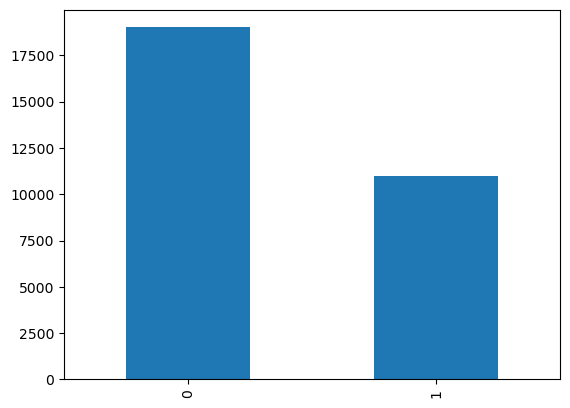

In [106]:
print(df2['is_duplicate'].value_counts())
print((df2['is_duplicate'].value_counts()/df2['is_duplicate'].count())*100)

df2['is_duplicate'].value_counts().plot(kind='bar')


In [107]:
qid=pd.Series(df2['qid1'].to_list() + df2['qid2'].to_list())
print("Number of unique questions",np.unique(qid).shape[0])

x=qid.value_counts()>1
print("Number of questions getting repeated", x[x].shape[0])

Number of unique questions 55299
Number of questions getting repeated 3480


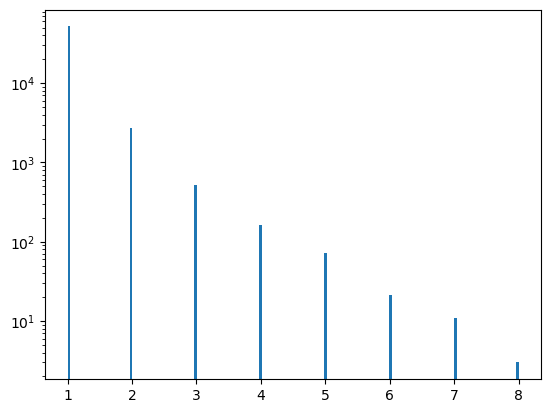

In [108]:
plt.hist(qid.value_counts().values, bins=160)
plt.yscale('log')
plt.show()

#### Feature Engineeering

In [109]:
df2['q1_len']=df2['question1'].str.len()
df2['q2_len']=df2['question2'].str.len()

In [110]:
df2.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1,76,77
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0,49,57
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0,105,120
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0,59,146
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0,35,50


In [111]:
df2['q1_num_words']=df2['question1'].apply(lambda row : len(row.split(" ")))
df2['q2_num_words']=df2['question2'].apply(lambda row : len(row.split(" ")))
df2.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1,76,77,12,12
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0,49,57,12,15
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0,105,120,25,17
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0,59,146,12,30
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0,35,50,5,9


In [112]:
def common_words(row):
    w1=set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    w2=set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))
    return len(w1&w2)

In [113]:
df2['common_word']=df2.apply(common_words,axis=1)
df2.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,common_word
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1,76,77,12,12,11
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0,49,57,12,15,7
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0,105,120,25,17,2
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0,59,146,12,30,0
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0,35,50,5,9,3


In [114]:
def total_words(row):
    w1=set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    w2=set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))
    return (len(w1)+len(w2))

In [115]:
df2['word_total']=df2.apply(total_words, axis=1)
df2.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,common_word,word_total
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1,76,77,12,12,11,24
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0,49,57,12,15,7,23
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0,105,120,25,17,2,34
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0,59,146,12,30,0,32
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0,35,50,5,9,3,13


In [116]:
df2['word_share']=round(df2['common_word']/df2['word_total'],2)
df2.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,common_word,word_total,word_share
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1,76,77,12,12,11,24,0.46
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0,49,57,12,15,7,23,0.30
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0,105,120,25,17,2,34,0.06
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0,59,146,12,30,0,32,0.00
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0,35,50,5,9,3,13,0.23


C:\Users\670285532\Anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


Minimum characters 2
Maximum characters 391
Average num of characters 59


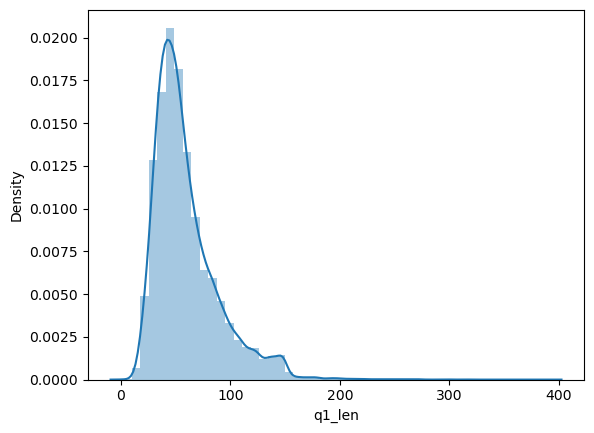

In [117]:
sns.distplot(df2['q1_len'])
print("Minimum characters", df2['q1_len'].min())
print("Maximum characters", df2['q1_len'].max())
print("Average num of characters", int(df2['q1_len'].mean()))

C:\Users\670285532\Anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


Minimum characters 6
Maximum characters 1151
Average num of characters 60


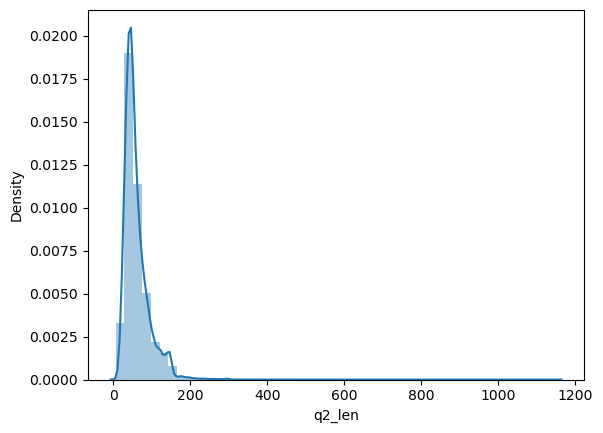

In [118]:
sns.distplot(df2['q2_len'])
print("Minimum characters", df2['q2_len'].min())
print("Maximum characters", df2['q2_len'].max())
print("Average num of characters", int(df2['q2_len'].mean()))

C:\Users\670285532\Anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


Minimum characters 1
Maximum characters 72
Average num of characters 10


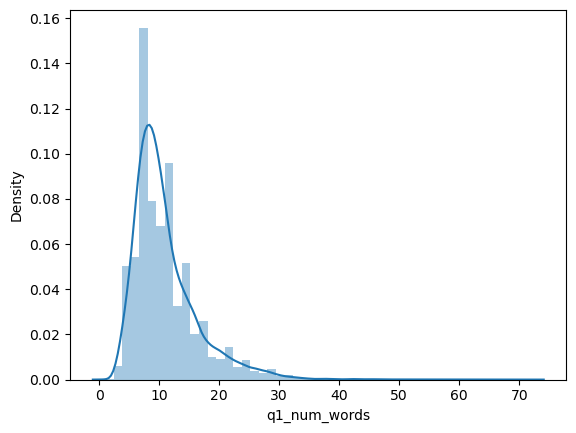

In [119]:
sns.distplot(df2['q1_num_words'])
print("Minimum characters", df2['q1_num_words'].min())
print("Maximum characters", df2['q1_num_words'].max())
print("Average num of characters", int(df2['q1_num_words'].mean()))

C:\Users\670285532\Anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


Minimum characters 1
Maximum characters 237
Average num of characters 11


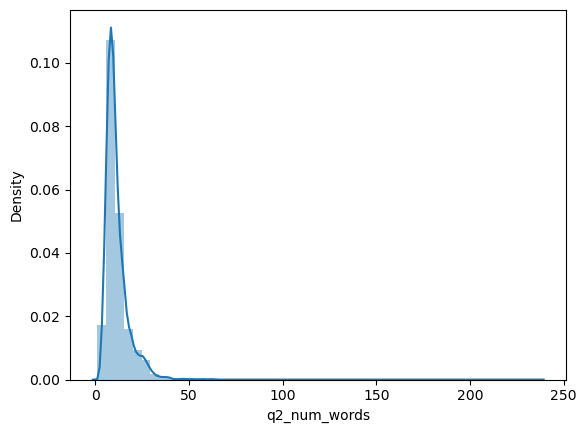

In [120]:
sns.distplot(df2['q2_num_words'])
print("Minimum characters", df2['q2_num_words'].min())
print("Maximum characters", df2['q2_num_words'].max())
print("Average num of characters", int(df2['q2_num_words'].mean()))

C:\Users\670285532\Anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
C:\Users\670285532\Anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


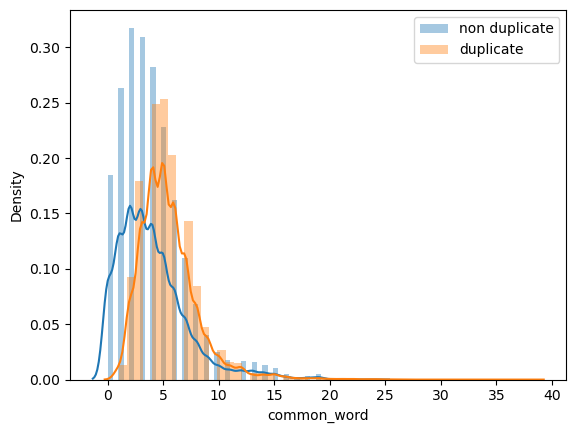

In [121]:
# common words
sns.distplot(df2[df2['is_duplicate'] == 0]['common_word'],label='non duplicate')
sns.distplot(df2[df2['is_duplicate'] == 1]['common_word'],label='duplicate')
plt.legend()
plt.show()

### If common words are more, then high chances of being duplciate questions else less chances

C:\Users\670285532\Anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
C:\Users\670285532\Anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


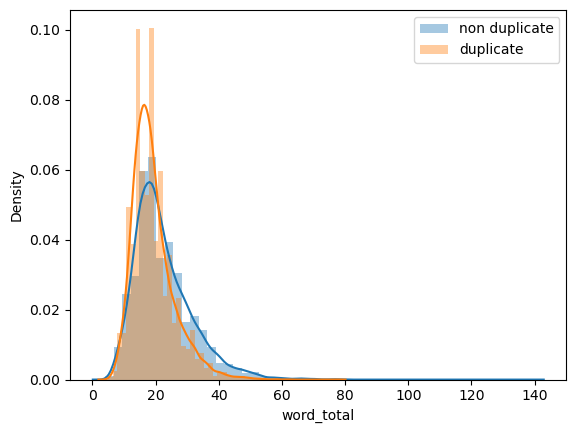

In [ ]:
# total words
sns.distplot(df2[df2['is_duplicate'] == 0]['word_total'],label='non duplicate')
sns.distplot(df2[df2['is_duplicate'] == 1]['word_total'],label='duplicate')
plt.legend()
plt.show()

### if the total words are more, then there are less chances of having duplicate questions while if total words are less, then duplicate chances are high

C:\Users\670285532\Anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
C:\Users\670285532\Anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


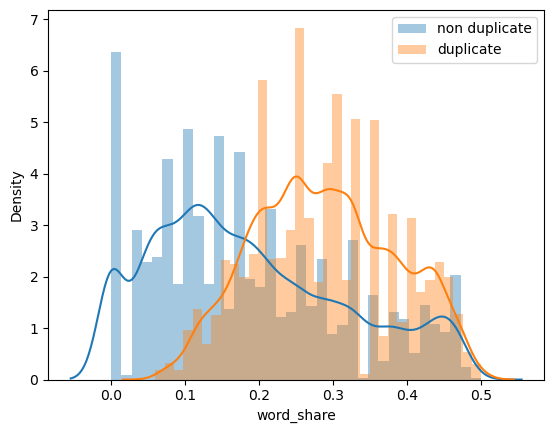

In [135]:
# word share
sns.distplot(df2[df2['is_duplicate'] == 0]['word_share'],label='non duplicate')
sns.distplot(df2[df2['is_duplicate'] == 1]['word_share'],label='duplicate')
plt.legend()
plt.show()

### if the word share of the common words in total words of questions is more, then high chances of being duplicates else less chance is there 
### for eg 0.4 word share means that the common words are higher, then we can say the chances of duplciates is high

In [136]:
ques_df = df2[['question1','question2']]
ques_df.head()

,question1,question2
398782,What is the best marketing automation tool for...,What is the best marketing automation tool for...
115086,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...
327711,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...
367788,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...
151235,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...


In [137]:
final_df = df2.drop(columns=['id','qid1','qid2','question1','question2'])
print(final_df.shape)
final_df.head()

(30000, 8)


,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,common_word,word_total,word_share
398782,1,76,77,12,12,11,24,0.46
115086,0,49,57,12,15,7,23,0.30
327711,0,105,120,25,17,2,34,0.06
367788,0,59,146,12,30,0,32,0.00
151235,0,35,50,5,9,3,13,0.23


In [138]:
from sklearn.feature_extraction.text import CountVectorizer

questions = list(ques_df['question1']) + list(ques_df['question2'])

cv = CountVectorizer(max_features=3000)
q1_arr, q2_arr = np.vsplit(cv.fit_transform(questions).toarray(),2)

In [139]:
temp_df1 = pd.DataFrame(q1_arr, index= ques_df.index)
temp_df2 = pd.DataFrame(q2_arr, index= ques_df.index)
temp_df = pd.concat([temp_df1, temp_df2], axis=1)
temp_df.shape

(30000, 6000)

In [140]:
final_df = pd.concat([final_df, temp_df], axis=1)
print(final_df.shape)
final_df.head()

(30000, 6008)


,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,common_word,word_total,word_share,0,1,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
398782,1,76,77,12,12,11,24,0.46,0,0,...,0,0,0,0,0,0,0,0,0,0
115086,0,49,57,12,15,7,23,0.30,0,0,...,0,0,0,0,0,0,0,0,0,0
327711,0,105,120,25,17,2,34,0.06,0,0,...,0,0,0,0,0,0,0,0,0,0
367788,0,59,146,12,30,0,32,0.00,0,0,...,0,0,0,1,0,0,0,0,0,0
151235,0,35,50,5,9,3,13,0.23,0,0,...,0,0,0,0,0,0,0,0,0,0


In [141]:
X=final_df.iloc[:,1:].values
y=final_df.iloc[:,0].values

In [144]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(final_df.iloc[:,1:].values,final_df.iloc[:,0].values,test_size=0.2,random_state=1)

In [145]:
X_train.shape

(24000, 6007)

In [146]:
y_train.shape

(24000,)

In [133]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf = RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.77

In [134]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train,y_train)
y_pred = xgb.predict(X_test)
accuracy_score(y_test,y_pred)

0.7661666666666667